KI  [MPa√m] = 9.43236123992319
KII [MPa√m] = 0.0


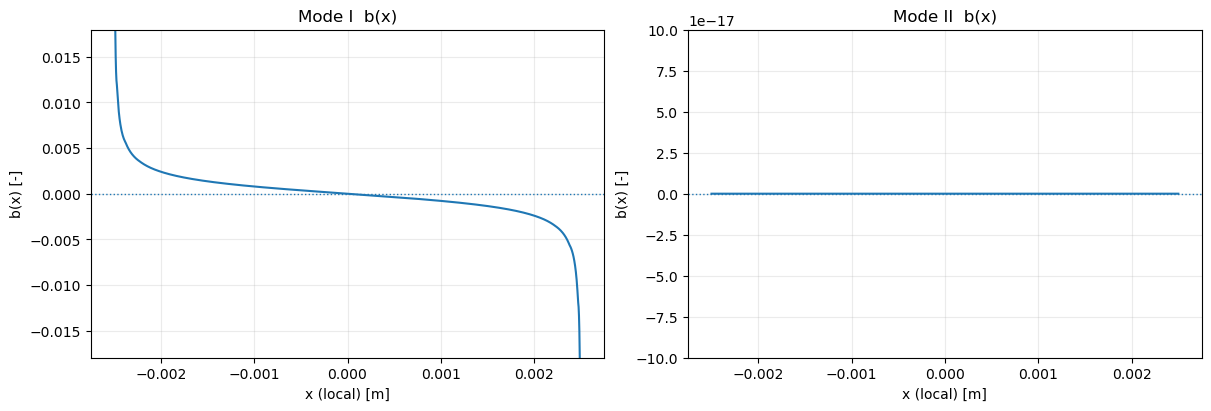

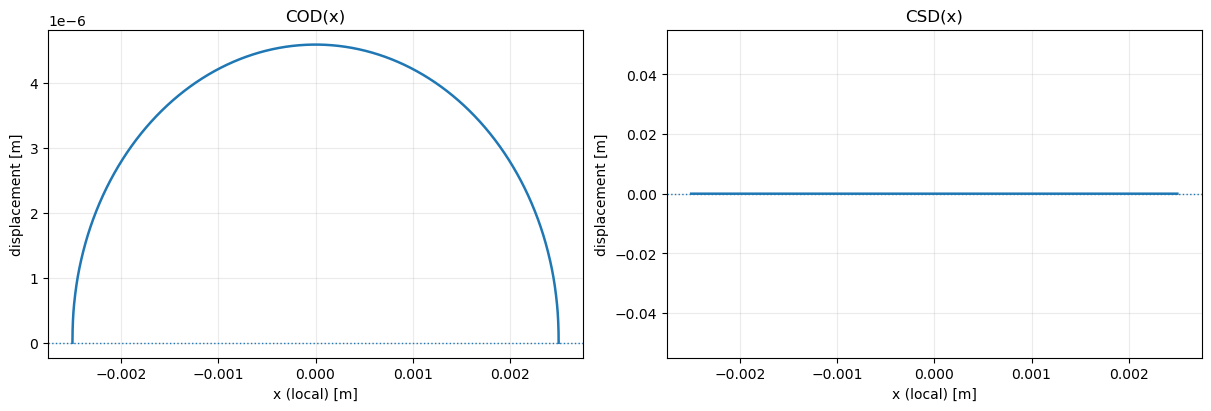

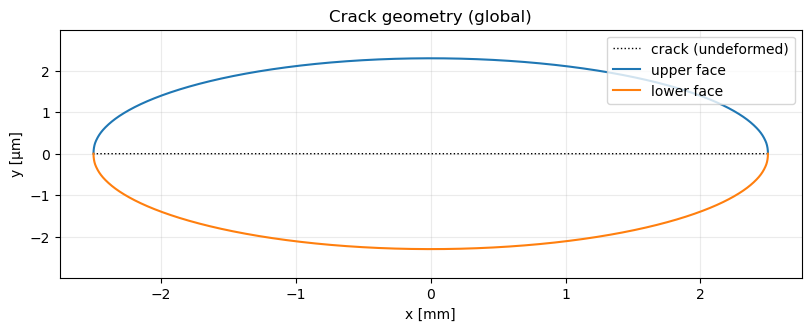

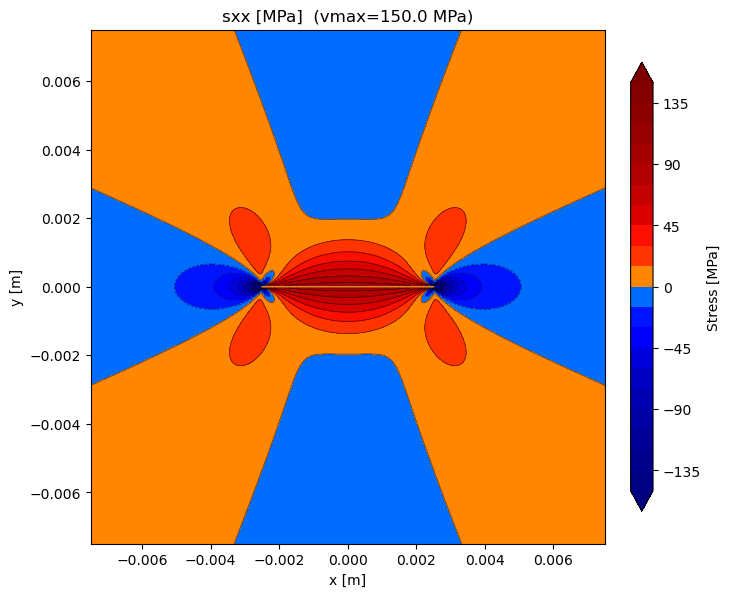

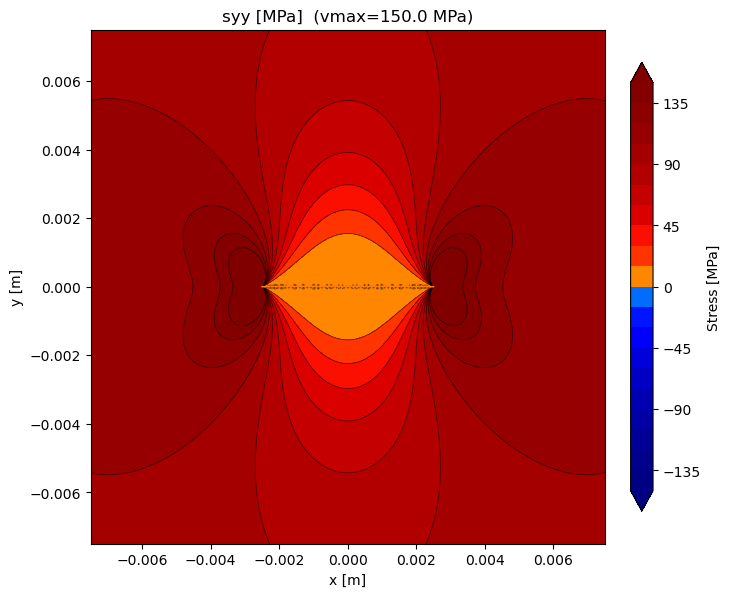

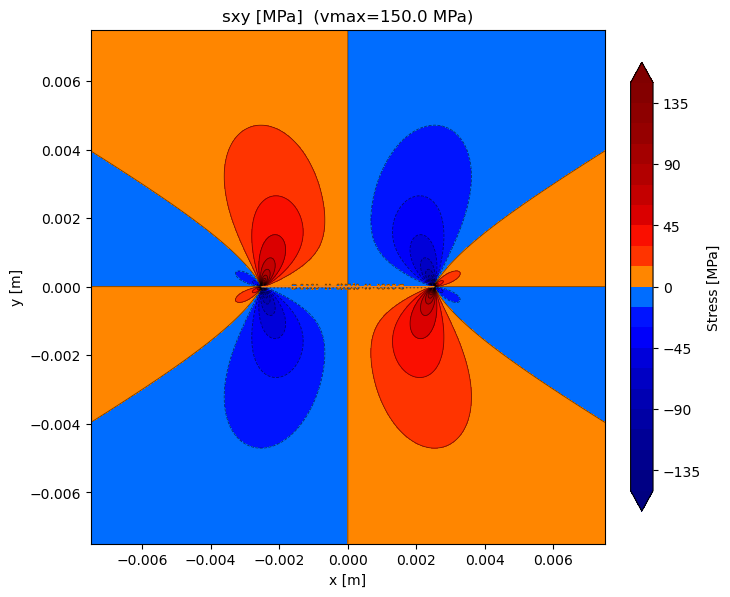

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\single_crack


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils.dce_solver_v2  as dsol
import utils.dce_results_v2 as dres
import utils.dce_plots_v2   as dplt
importlib.reload(dsol); importlib.reload(dres); importlib.reload(dplt)

from utils.dce_solver_v2  import Material, Crack, AppliedStress, DCESingleCrackStatic
from utils.dce_results_v2 import DCEResultsV2
from utils.dce_plots_v2   import DCEPlotterV2, StressPlotOpts

# -------------------------
# Output directory (ALL figures saved here)
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\single_crack")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem setup
# -------------------------
ne_half = 10
L = 5e-3  # crack length 2a [m]

material = Material(E=200e9, nu=0.30, plane_stress=False)
crack    = Crack(length=L, angle=0.0, center=(0.0, 0.0))
stress   = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)  # Pa

calc = DCESingleCrackStatic(material, crack, stress)

sol = calc.solve(
    ne_half=ne_half,
    representation="cheb_quad",      # robust baseline
    node_distribution="tip_dense",   # recommended
)
# sol = calc.solve(50)
res = DCEResultsV2(calc, sol)
plotter = DCEPlotterV2(res, out_dir=out_dir)

# -------------------------
# Stress intensity factors
# -------------------------
KI, KII, meta = res.sif_from_cod_fit(tip="right")
print("KI  [MPa√m] =", KI / 1e6)
print("KII [MPa√m] =", KII / 1e6)

# -------------------------
# Basic plots
# -------------------------
plotter.plot_burgers()
plotter.plot_cod_csd(n_theta=8000)
plotter.plot_crack_geometry(n_theta=2000, scale=1.0)  # y-axis in microns
plt.show()

# -------------------------
# Global stress plots (bands + contours)
# -------------------------
opts = StressPlotOpts(
    extent_factor=3,
    n_grid=401,
    add_remote=True,        # IMPORTANT: makes far field ~100 MPa for syy
    mask_crack=True,
    cmap="jet",
    n_bands=20,
    label_contours=False,
    vmax_factor=1.5,        # try 3, 5, 10 for tip emphasis
)

figs = plotter.plot_stress_components_global(
    opts=opts,
    components=("sxx", "syy", "sxy"),
)
plt.show()

print("Saved figures to:", out_dir)


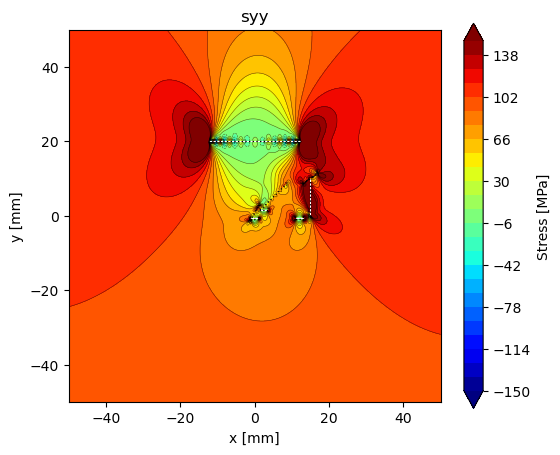

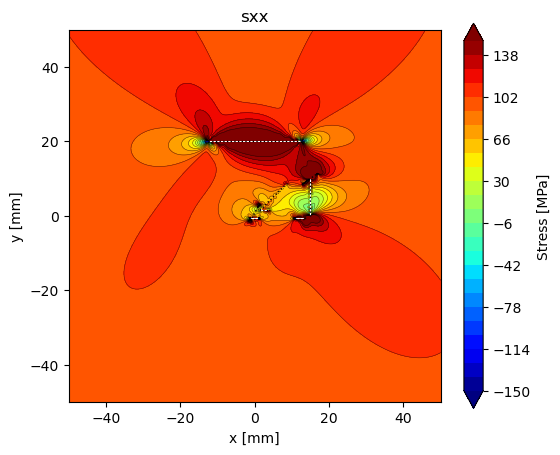

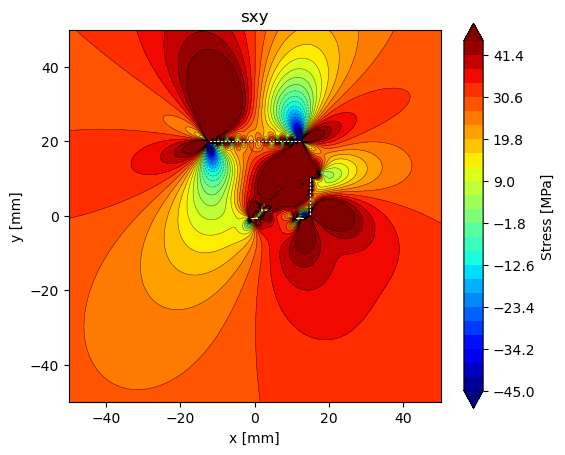

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\two_cracks


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root on path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

from utils.dce_solver_v3  import Material, Crack, AppliedStress, DCEMultiCrackStatic
from utils.dce_results_v3 import DCEResultsV3
from utils.dce_plots_v3   import DCEPlotterV3, StressPlotOpts

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\two_cracks")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Material + remote loading
# -------------------------
material = Material(E=200e9, nu=0.30, plane_stress=False)
stress   = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=30e6)

# -------------------------
# Two interacting cracks
# -------------------------
L = 5e-3      # 2a = 5 mm
a = L/2
gap = 0.6*a   # close enough to interact strongly
pi=np.pi
cracks = [
    Crack(length=L, angle=pi/3, center=(0.0, +0.5*gap)),
    Crack(length=L/2, angle=0.0, center=(0.0, -0.5*gap)),
    Crack(length=2*L, angle=pi/4, center=(L, L)),
    Crack(length=L/2, angle=0.0, center=(L/2, gap)),
    Crack(length=L, angle=pi/5, center=(3*L, 2*L)),
    Crack(length=L/2, angle=pi, center=(2.4*L, -0.5*gap)),
    Crack(length=2*L, angle=pi/2, center=(3*L, L)),
    Crack(length=5*L, angle=0.0, center=(0, 4*L)),
]

calc = DCEMultiCrackStatic(material, cracks, stress)

sol = calc.solve(
    ne_half=6,
    representation="cheb_quad",      # try "cheb_spectral" as well
    node_distribution="tip_dense",
    nq_col=3,
    nq_stress=6,
    ridge=1e-14,
)

res = DCEResultsV3(calc, sol)
plotter = DCEPlotterV3(res, out_dir=out_dir)

opts = StressPlotOpts(
    extent_factor=4.0,
    n_grid=401,
    add_remote=True,
    mask_crack=True,
    cmap="jet",
    n_bands=25,
    label_contours=False,
    vmax_factor=1.5,
)

plotter.plot_stress_components_global(opts, components=("syy","sxx","sxy"))
plt.show()

print("Saved figures to:", out_dir)
